In [1]:
pkgs <- c(
  "tidymodels",
  'glmnet',
  "rstanarm", 
  "reticulate",
  'yardstick'
)
instalar <- pkgs[!pkgs %in% installed.packages()[, "Package"]]

if (length(instalar) > 0) {
  install.packages(instalar)
}
library(caret)
library(tidyverse)
library("tidymodels")
library('janitor')
library('ggcorrplot')
library(workflowsets)
library(rstanarm)
library(glmnet)
library(reticulate)
library(ggplot2)
library(patchwork)
library(dplyr)

py_config()
reticulate::py_install(c("pandas", "tabulate", "ipython"))

set.seed(42)

Carregando pacotes exigidos: ggplot2

Carregando pacotes exigidos: lattice

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ purrr::lift()   masks caret::lift()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.5.0 ──

✔ broom        1.0.12     ✔ rsample      1.3.2 
✔ dials        1.4.3      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.5.0      ✔ workflowsets 1.1.1 
✔ recipes      1.3.2      ✔ yardstick    1.4.0 

── Conflicts ─

Error in python_config_impl(python) : 
  Error 103 occurred running C:/Users/T-GAMER/OneDrive/Documentos/.virtualenvs/r-reticulate/Scripts/python.exe: 


python:         C:/Users/T-GAMER/AppData/Local/R/cache/R/reticulate/uv/cache/archive-v0/Z7yLGySVAB_TMH-wsihzG/Scripts/python.exe
libpython:      C:/Users/T-GAMER/AppData/Local/R/cache/R/reticulate/uv/python/cpython-3.12.13-windows-x86_64-none/python312.dll
pythonhome:     C:/Users/T-GAMER/AppData/Local/R/cache/R/reticulate/uv/cache/archive-v0/Z7yLGySVAB_TMH-wsihzG
virtualenv:     C:/Users/T-GAMER/AppData/Local/R/cache/R/reticulate/uv/cache/archive-v0/Z7yLGySVAB_TMH-wsihzG/Scripts/activate_this.py
version:        3.12.13 (main, Apr 14 2026, 14:31:26) [MSC v.1944 64 bit (AMD64)]
Architecture:   64bit
numpy:          C:/Users/T-GAMER/AppData/Local/R/cache/R/reticulate/uv/cache/archive-v0/Z7yLGySVAB_TMH-wsihzG/Lib/site-packages/numpy
numpy_version:  2.5.1

NOTE: Python version was forced by py_require()

Warning message in reticulate::py_install(c("pandas", "tabulate", "ipython")):
"An ephemeral virtual environment managed by 'reticulate' is currently in use.
To add more packages to your current session, call `py_require()` instead
of `py_install()`. Running:
  `py_require(c("pandas", "tabulate", "ipython"))`"


In [2]:
loan <- read_csv("data/Loan/loan_approval_dataset.csv") |>
  clean_names()

#https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
default <- read_csv("data/default/UCI_Credit_Card.csv")

Rows: 4269 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): education, self_employed, loan_status
dbl (10): loan_id, no_of_dependents, income_annum, loan_amount, loan_term, c...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 30000 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (25): ID, LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE, PAY_0, PAY_2, PAY_3,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
loan <- loan %>%
  rename(
    num_dependentes      = no_of_dependents,
    escolaridade         = education,
    autonomo             = self_employed,
    renda_anual          = income_annum,
    valor_emprestimo     = loan_amount,
    prazo_anos           = loan_term,
    score_credito        = cibil_score,
    ativos_residenciais  = residential_assets_value,
    ativos_comerciais    = commercial_assets_value,
    ativos_luxo          = luxury_assets_value,
    ativos_bancarios     = bank_asset_value,
    status    = loan_status
)

loan <- loan %>%
  dplyr::select(-loan_id)

loan$status <- ifelse(
  loan$status %in% c("Approved", 1, "1"),
  1, 0
)
loan$status <- as.factor(loan$status)

In [4]:
default <- default %>%
  rename(
    id_cliente = ID,
    limite_credito = LIMIT_BAL,
    sexo = SEX,
    escolaridade = EDUCATION,
    estado_civil = MARRIAGE,
    idade = AGE,
    atraso_pagto_0 = PAY_0,
    atraso_pagto_2 = PAY_2,
    atraso_pagto_3 = PAY_3,
    atraso_pagto_4 = PAY_4,
    atraso_pagto_5 = PAY_5,
    atraso_pagto_6 = PAY_6,
    fatura_valor_1 = BILL_AMT1,
    fatura_valor_2 = BILL_AMT2,
    fatura_valor_3 = BILL_AMT3,
    fatura_valor_4 = BILL_AMT4,
    fatura_valor_5 = BILL_AMT5,
    fatura_valor_6 = BILL_AMT6,
    pagto_valor_1 = PAY_AMT1,
    pagto_valor_2 = PAY_AMT2,
    pagto_valor_3 = PAY_AMT3,
    pagto_valor_4 = PAY_AMT4,
    pagto_valor_5 = PAY_AMT5,
    pagto_valor_6 = PAY_AMT6,
    PD30 = default.payment.next.month
)
default <- default %>%
  dplyr::select(-id_cliente)

default$PD30 <- as.factor(default$PD30)

In [5]:
library(dplyr)
library(readr)
library(tibble)

corr <- default %>%
  select(where(is.numeric)) %>%
  cor(use = "pairwise.complete.obs")

corr_df <- corr %>%
  as.data.frame() %>%
  rownames_to_column("variavel")

write_csv(corr_df, "correlacao.csv")

In [6]:
split_loan <- initial_split(
  loan,
  prop   = 0.75,
  strata = status
)

train_data_loan <- training(split_loan)
test_data_loan  <- testing(split_loan)

split_default <- initial_split(
  default,
  prop   = 0.75,
  strata = PD30
)

train_data_default <- training(split_default)
test_data_default  <- testing(split_default)

In [7]:
log_glm <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification")
#lasso
log_l1 <- logistic_reg(
  penalty = tune(),
  mixture = 1
) |>
  set_engine("glmnet") |>
  set_mode("classification")

log_l2 <- logistic_reg(
  penalty = tune(),
  mixture = 0
) |>
  set_engine("glmnet") |>
  set_mode("classification")


In [8]:
folds <- vfold_cv(train_data_loan, v = 5, strata = status)
grid <- grid_regular(
  penalty(range = c(-6, 1)),
  levels = 20
)
metrics <- metric_set(
  accuracy,
  roc_auc,
  f_meas
)

In [9]:
#
rec_all <- recipe(status ~ ., data = train_data_loan) %>%
  step_dummy(all_nominal_predictors())


rec_def <- recipe(status ~ ., data = train_data_loan) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())

rec_score_only <- recipe(
  status ~ score_credito,
  data = train_data_loan
)%>%
  step_dummy(all_nominal_predictors())

rec_score_prazo <- recipe(
  status ~ score_credito + prazo_anos,
  data = train_data_loan
)%>%
  step_dummy(all_nominal_predictors())

rec_no_score <- recipe(
  status ~ .,
  data = train_data_loan
) %>%
  step_dummy(all_nominal_predictors())%>%
  step_rm(score_credito)

rec_no_corr <- recipe(
  status ~ .,
  data = train_data_loan
) %>%
  step_dummy(all_nominal_predictors())%>%
  step_corr(all_numeric_predictors(), threshold = 0.75)

rec_pca <- recipe(
  status ~ .,
  data = train_data_loan
) %>%
  step_dummy(all_nominal_predictors())%>%
  step_normalize(all_numeric_predictors()) %>% 
  step_pca(
    all_numeric_predictors(),
    threshold = 0.95
  )

In [10]:
wf_logit <- workflow_set(
  preproc = list(
    all_features = rec_all,
    score_only   = rec_score_only,
    #score_prazo  = rec_score_prazo,
    no_score     = rec_no_score,
    no_corr      = rec_no_corr
    #pca          = rec_pca
  ),
  models = list(
    logit = log_glm
  )
)

wf_l1 <- workflow() %>%
  add_recipe(rec_def) %>%
  add_model(log_l1)

tuned_l1 <- tune_grid(
  wf_l1,
  resamples = folds,
  grid = grid,
  metrics = metrics
)

wf_l2 <- workflow() %>%
  add_recipe(rec_def) %>%
  add_model(log_l2)

tuned_l2 <- tune_grid(
  wf_l2,
  resamples = folds,
  grid = grid,
  metrics = metrics
)

→ A | warning: While computing binary `precision()`, no predicted events were detected (i.e.
               `true_positive + false_positive = 0`).
               Precision is undefined in this case, and `NA` will be returned.
               Note that 242 true event(s) actually occurred for the problematic event level,
               0

There were issues with some computations   A: x5

→ B | warning: While computing binary `precision()`, no predicted events were detected (i.e.
               `true_positive + false_positive = 0`).
               Precision is undefined in this case, and `NA` will be returned.
               Note that 241 true event(s) actually occurred for the problematic event level,
               0

There were issues with some computations   A: x5
There were issues with some computations   A: x20   B: x5



→ A | warning: While computing binary `precision()`, no predicted events were detected (i.e.
               `true_positive + false_positive = 0`).
               Pr

In [11]:
best_l1 <- select_best(tuned_l1, metric = "roc_auc")
final_l1 <- finalize_workflow(wf_l1, best_l1)
fit_l1 <- fit(final_l1, train_data_loan)

best_l2 <- select_best(tuned_l2, metric = "roc_auc")
final_l2 <- finalize_workflow(wf_l2, best_l2)
fit_l2 <- fit(final_l2, train_data_loan)

In [12]:
library(broom)

coef_table <- extract_fit_engine(fit_l1) |>
  coef(s = best_l1$penalty)
  coef_table

12 x 1 sparse Matrix of class "dgCMatrix"
                          s=0.002069138
(Intercept)                 1.600776070
num_dependentes            -0.014641491
renda_anual                -0.730093148
valor_emprestimo            0.770600810
prazo_anos                 -0.723077756
score_credito               3.840293624
ativos_residenciais         0.003759789
ativos_comerciais           .          
ativos_luxo                 .          
ativos_bancarios            .          
escolaridade_Not.Graduate  -0.043215805
autonomo_Yes                0.011867517

In [13]:
coef_table <- extract_fit_engine(fit_l2) |>
  coef(s = best_l2$penalty)
  coef_table

12 x 1 sparse Matrix of class "dgCMatrix"
                               s=1e-06
(Intercept)                0.866116295
num_dependentes           -0.037874893
renda_anual               -0.096195929
valor_emprestimo           0.151951996
prazo_anos                -0.304510853
score_credito              1.886966643
ativos_residenciais        0.001744485
ativos_comerciais          0.012621253
ativos_luxo               -0.032643489
ativos_bancarios          -0.028225852
escolaridade_Not.Graduate -0.025509484
autonomo_Yes               0.015458053

In [14]:
fits <- wf_logit %>%
  mutate(
    fit = purrr::map(
      info,
      ~ fit(.x$workflow[[1]], data = train_data_loan)
    )
  )

In [15]:
library(dplyr)
library(purrr)
library(yardstick)



In [16]:
preds_loan <- fits %>%
  mutate(
    pred_list = map(
      fit,
      ~{
        prob_tbl <- predict(.x, test_data_loan, type = "prob")

        tibble(
          truth = test_data_loan$status,
          class = predict(.x, test_data_loan, type = "class")$.pred_class,
          prob  = prob_tbl$.pred_1
        )
      }
    )
  ) %>%
  select(wflow_id, pred_list) %>%
  tidyr::unnest(pred_list)

In [17]:
library(tibble)
library(yardstick)

#old version

calc_metrics_from_fit <- function(fit, test_data, truth_col = status) {

  # predições
  prob_tbl  <- predict(fit, test_data, type = "prob")
  class_tbl <- predict(fit, test_data, type = "class")

  truth <- test_data[[deparse(substitute(truth_col))]]
  class <- class_tbl$.pred_class
  prob  <- prob_tbl$.pred_1

  tibble(
    accuracy     = accuracy_vec(truth, class),
    bal_accuracy = bal_accuracy_vec(truth, class),

    roc_auc  = roc_auc_vec(truth, prob, event_level = "second"),
    log_loss = mn_log_loss_vec(truth, prob),
    brier    = brier_class_vec(truth, prob),

    sens = sens_vec(truth, class),
    spec = spec_vec(truth, class),

    precision = precision_vec(truth, class),
    npv       = npv_vec(truth, class),

    f1 = f_meas_vec(truth, class),
    f2 = f_meas_vec(truth, class, beta = 2),

    kap = kap_vec(truth, class),
    mcc = mcc_vec(truth, class),

    gmean = sqrt(
      sens_vec(truth, class) * spec_vec(truth, class)
    )
  )
}

In [18]:
calc_metrics_from_fit <- function(fit, test_data, truth_col = status) {

  # Predições
  prob_tbl  <- predict(fit, test_data, type = "prob")
  class_tbl <- predict(fit, test_data, type = "class")

  truth <- test_data[[deparse(substitute(truth_col))]]
  class <- class_tbl$.pred_class

  # Classe positiva
  positive_class <- levels(truth)[2]

  # Probabilidade da classe positiva
  prob <- prob_tbl[[paste0(".pred_", positive_class)]]

  # Resposta em 0/1
  truth_num <- as.numeric(truth == positive_class)

  # Evita log(0)
  eps <- 1e-15
  prob_clip <- pmin(pmax(prob, eps), 1 - eps)

  # Log Loss
  log_loss <- -mean(
    truth_num * log(prob_clip) +
      (1 - truth_num) * log(1 - prob_clip)
  )

  # Brier Score
  brier <- mean((prob - truth_num)^2)

  tibble(
    accuracy     = accuracy_vec(truth, class),
    bal_accuracy = bal_accuracy_vec(truth, class),

    roc_auc  = roc_auc_vec(truth, prob, event_level = "second"),
    log_loss = log_loss,
    brier    = brier,

    sens = sens_vec(truth, class),
    spec = spec_vec(truth, class),

    precision = precision_vec(truth, class),
    npv       = npv_vec(truth, class),

    f1 = f_meas_vec(truth, class),
    f2 = f_meas_vec(truth, class, beta = 2),

    kap = kap_vec(truth, class),
    mcc = mcc_vec(truth, class),

    gmean = sqrt(
      sens_vec(truth, class) *
      spec_vec(truth, class)
    )
  )
}

In [19]:
calc_metrics_from_fit <- function(fit, test_data, truth_col = status) {

  # Predições
  prob_tbl  <- predict(fit, test_data, type = "prob")
  class_tbl <- predict(fit, test_data, type = "class")

  truth <- test_data[[deparse(substitute(truth_col))]]
  class <- class_tbl$.pred_class

  # Classe positiva
  positive_class <- levels(truth)[2]

  # Probabilidade da classe positiva
  prob <- prob_tbl[[paste0(".pred_", positive_class)]]

  # Resposta em 0/1
  truth_num <- as.numeric(truth == positive_class)

  # Evita log(0)
  eps <- 1e-15
  prob_clip <- pmin(pmax(prob, eps), 1 - eps)

  # Log Loss
  log_loss <- -mean(
    truth_num * log(prob_clip) +
      (1 - truth_num) * log(1 - prob_clip)
  )

  # Brier Score
  brier <- mean((prob - truth_num)^2)

  tibble(
    accuracy     = accuracy_vec(truth, class),
    bal_accuracy = bal_accuracy_vec(truth, class),

    roc_auc  = roc_auc_vec(truth, prob, event_level = "second"),
    log_loss = log_loss,
    #brier    = brier,

    sens = sens_vec(truth, class),
    spec = spec_vec(truth, class),

    precision = precision_vec(truth, class),
    #npv       = npv_vec(truth, class),

    f1 = f_meas_vec(truth, class),
    #f2 = f_meas_vec(truth, class, beta = 2),

    #kap = kap_vec(truth, class),
    mcc = mcc_vec(truth, class),

    #gmean = sqrt(
    #  sens_vec(truth, class) *
    #  spec_vec(truth, class)
    #)
  )
}

In [20]:
metrics_wf <- fits %>%
  mutate(
    metrics = purrr::map(
      fit,
      ~ calc_metrics_from_fit(
        fit = .x,
        test_data = test_data_loan,
        truth_col = status
      )
    )
  ) %>%
  select(wflow_id, metrics) %>%
  tidyr::unnest(metrics)


metrics_l1 <- calc_metrics_from_fit(
  fit = fit_l1,
  test_data = test_data_loan,
  truth_col = status
) %>%
  mutate(wflow_id = "l1_logit")

metrics_l2 <- calc_metrics_from_fit(
  fit = fit_l2,
  test_data = test_data_loan,
  truth_col = status
) %>%
  mutate(wflow_id = "l2_logit")

metrics_table_final_loan <- bind_rows(
  metrics_wf,
  metrics_l1,
  metrics_l2
)
metrics_table_final_loan

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,f1,mcc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9269663,0.9228498,0.9762018,0.1951876,0.90594059,0.9397590,0.9014778,0.90370370,0.84488744
score_only_logit,0.9213483,0.9173625,0.9651769,0.2362452,0.90099010,0.9337349,0.8921569,0.89655172,0.83313641
no_score_logit,0.6207865,0.5065162,0.6161838,0.6461995,0.03712871,0.9759036,0.4838710,0.06896552,0.03764666
no_corr_logit,0.9307116,0.9278003,0.9736334,0.2061840,0.91584158,0.9397590,0.9024390,0.90909091,0.85318053
l1_logit,0.9260300,0.9220968,0.9760154,0.1997227,0.90594059,0.9382530,0.8992629,0.90258940,0.84298306
l2_logit,0.9269663,0.9199421,0.9743342,0.2802624,0.89108911,0.9487952,0.9137056,0.90225564,0.84414319


In [21]:
extract_model_summary <- function(wf_fit) {
  model_fit <- workflows::extract_fit_parsnip(wf_fit)

  if (inherits(model_fit$fit, "glm")) {
    return(summary(model_fit$fit))
  }

  if (inherits(model_fit$fit, "lognet")) {
    return(model_fit$fit)
  }

  NULL
}

In [22]:
model_summaries <- fits %>%
  mutate(
    summary = purrr::map(fit, extract_model_summary)
  ) %>%
  select(wflow_id, summary)
  
for (i in seq_len(nrow(model_summaries))) {
  cat("\n==============================\n")
  cat("Modelo:", model_summaries$wflow_id[i], "\n")
  cat("==============================\n\n")
  print(model_summaries$summary[[i]])
}


Modelo: all_features_logit 


Call:
stats::glm(formula = ..y ~ ., family = stats::binomial, data = data)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -1.073e+01  4.785e-01 -22.422  < 2e-16 ***
num_dependentes           -2.446e-02  3.988e-02  -0.613    0.540    
renda_anual               -5.785e-07  1.028e-07  -5.629 1.82e-08 ***
valor_emprestimo           1.369e-07  2.055e-08   6.662 2.71e-11 ***
prazo_anos                -1.432e-01  1.287e-02 -11.120  < 2e-16 ***
score_credito              2.366e-02  9.076e-04  26.068  < 2e-16 ***
ativos_residenciais        1.262e-08  1.330e-08   0.949    0.343    
ativos_comerciais          1.307e-08  1.962e-08   0.666    0.505    
ativos_luxo                2.658e-08  1.989e-08   1.336    0.181    
ativos_bancarios           3.961e-08  3.804e-08   1.041    0.298    
escolaridade_Not.Graduate -1.679e-01  1.347e-01  -1.247    0.212    
autonomo_Yes               6.747e-02  1.338e-01   0

In [23]:
fits_vif <- fits %>%
  dplyr::filter(
    wflow_id %in% c(
      "all_features_logit",
      "no_corr_logit",
      "no_score_logit",
      "feat_select_logit"
    )
  )



In [24]:
library(car)

calc_vif <- function(wf_fit) {
  wf_fit %>%
    workflows::extract_fit_parsnip() %>%
    pluck("fit") %>%      # objeto glm
    car::vif()
}

vif_results <- fits_vif %>%
  mutate(
    vif = purrr::map(fit, calc_vif)
  )

Carregando pacotes exigidos: carData

Registered S3 method overwritten by 'car':
  method           from
  na.action.merMod lme4


Anexando pacote: 'car'


O seguinte objeto é mascarado por 'package:rstanarm':

    logit


O seguinte objeto é mascarado por 'package:dplyr':

    recode


O seguinte objeto é mascarado por 'package:purrr':

    some




In [25]:
vif_tidy <- vif_results %>%
  select(wflow_id, vif) %>%
  tidyr::unnest_longer(vif, values_to = "vif") %>%
  rename(variable = vif_id)

In [26]:
vif_summary <- vif_tidy %>%
  group_by(wflow_id) %>%
  summarise(
    max_vif = max(vif),
    mean_vif = mean(vif)
  )
vif_summary

wflow_id,max_vif,mean_vif
<chr>,<dbl>,<dbl>
all_features_logit,18.667257,4.225453
no_corr_logit,1.586206,1.226418
no_score_logit,17.106545,4.227158


In [27]:
library(dplyr)

model_summary <- metrics_table_final_loan %>%
  left_join(
    vif_summary %>%
      group_by(wflow_id) %>%
      summarise(
        max_vif = max(max_vif, na.rm = TRUE),
        mean_vif = mean(mean_vif, na.rm = TRUE)
      ),
    by = "wflow_id"
  )
model_summary

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,f1,mcc,max_vif,mean_vif
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9269663,0.9228498,0.9762018,0.1951876,0.90594059,0.9397590,0.9014778,0.90370370,0.84488744,18.667257,4.225453
score_only_logit,0.9213483,0.9173625,0.9651769,0.2362452,0.90099010,0.9337349,0.8921569,0.89655172,0.83313641,NA,NA
no_score_logit,0.6207865,0.5065162,0.6161838,0.6461995,0.03712871,0.9759036,0.4838710,0.06896552,0.03764666,17.106545,4.227158
no_corr_logit,0.9307116,0.9278003,0.9736334,0.2061840,0.91584158,0.9397590,0.9024390,0.90909091,0.85318053,1.586206,1.226418
l1_logit,0.9260300,0.9220968,0.9760154,0.1997227,0.90594059,0.9382530,0.8992629,0.90258940,0.84298306,NA,NA
l2_logit,0.9269663,0.9199421,0.9743342,0.2802624,0.89108911,0.9487952,0.9137056,0.90225564,0.84414319,NA,NA


In [28]:
get_model <- function(wf_fit) {
  workflows::extract_fit_parsnip(wf_fit)$fit
}

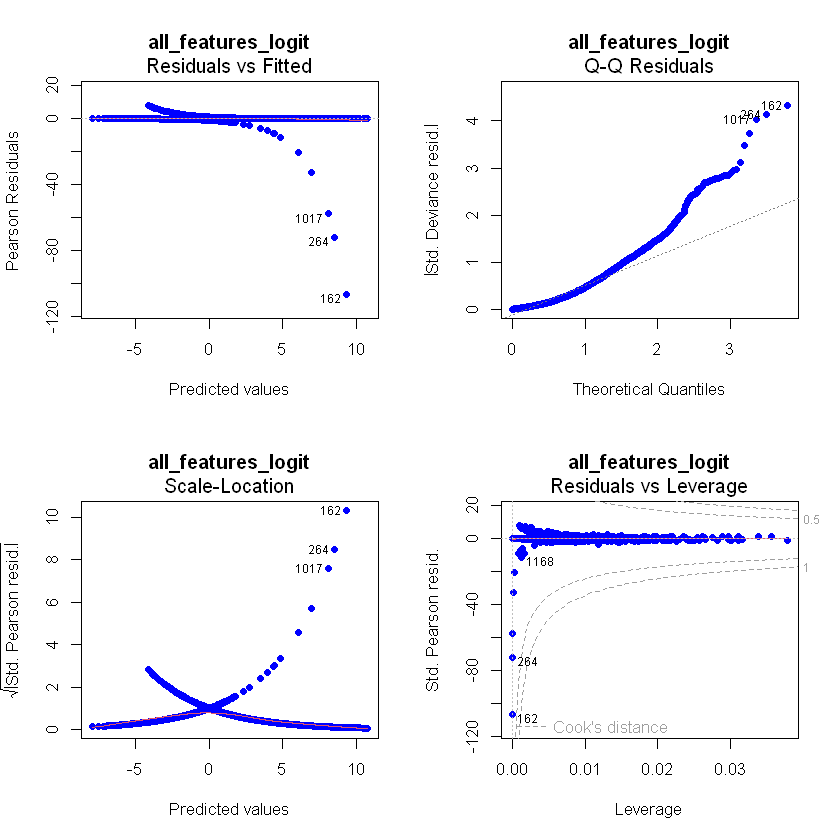

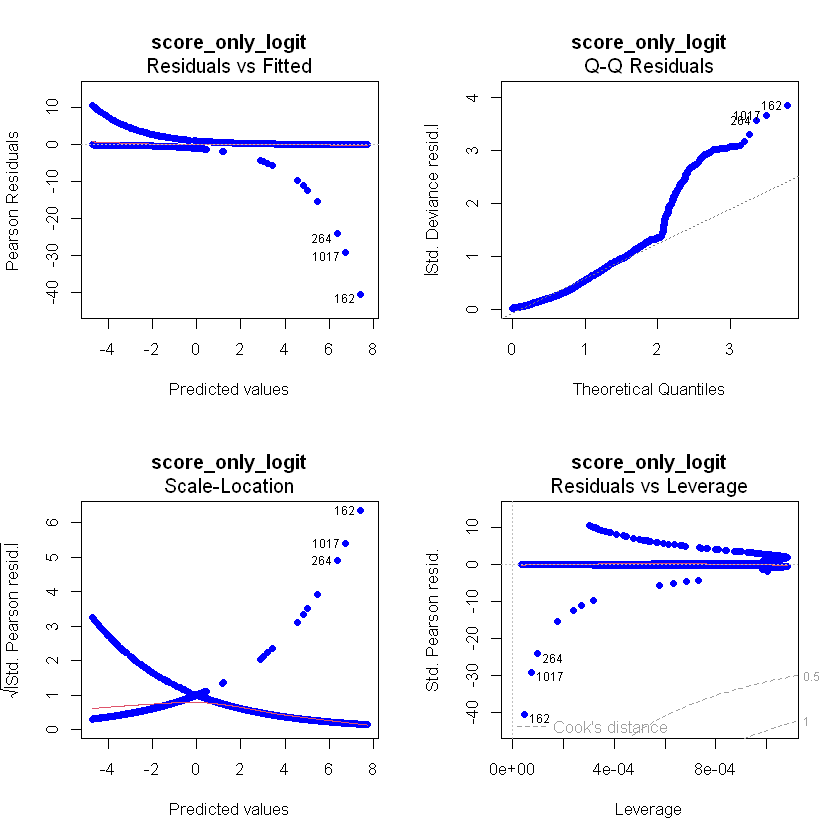

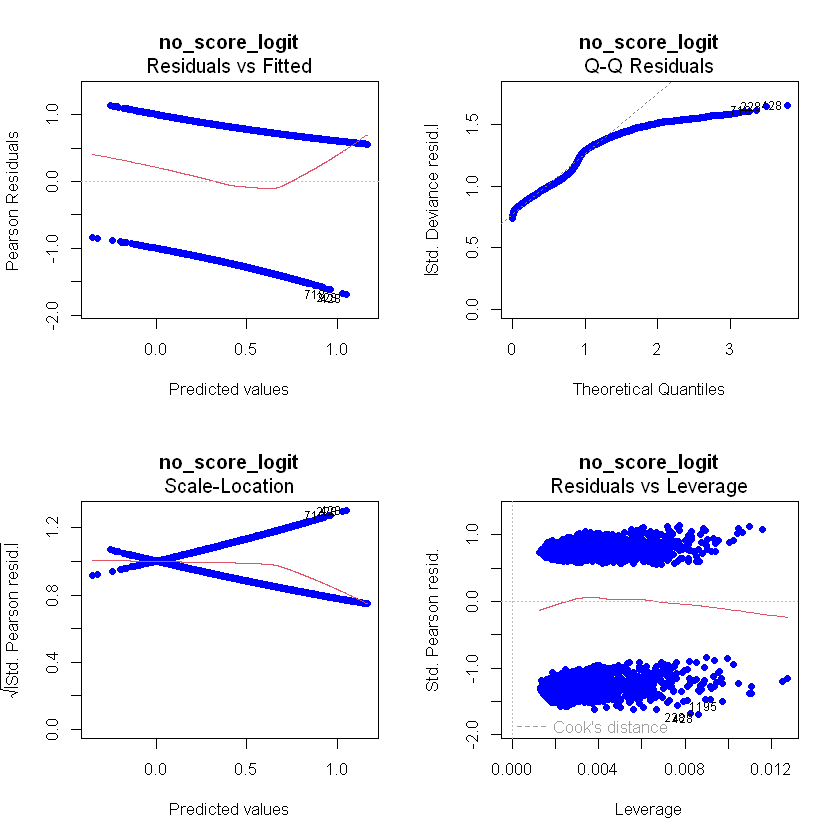

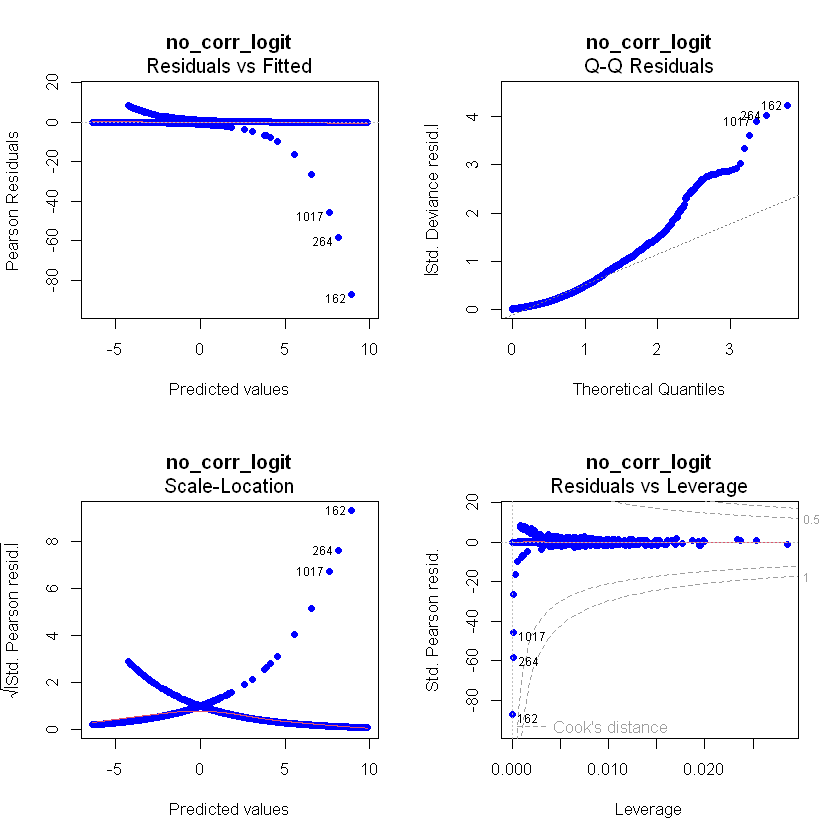

In [29]:
purrr::walk2(
  fits$fit,
  fits$wflow_id,
  ~ {
    modelo <- get_model(.x)

    par(mfrow = c(2, 2))
    plot(
      modelo,
      pch = 19,
      col = "blue",
      main = .y
    )
  }
)

[1] 486

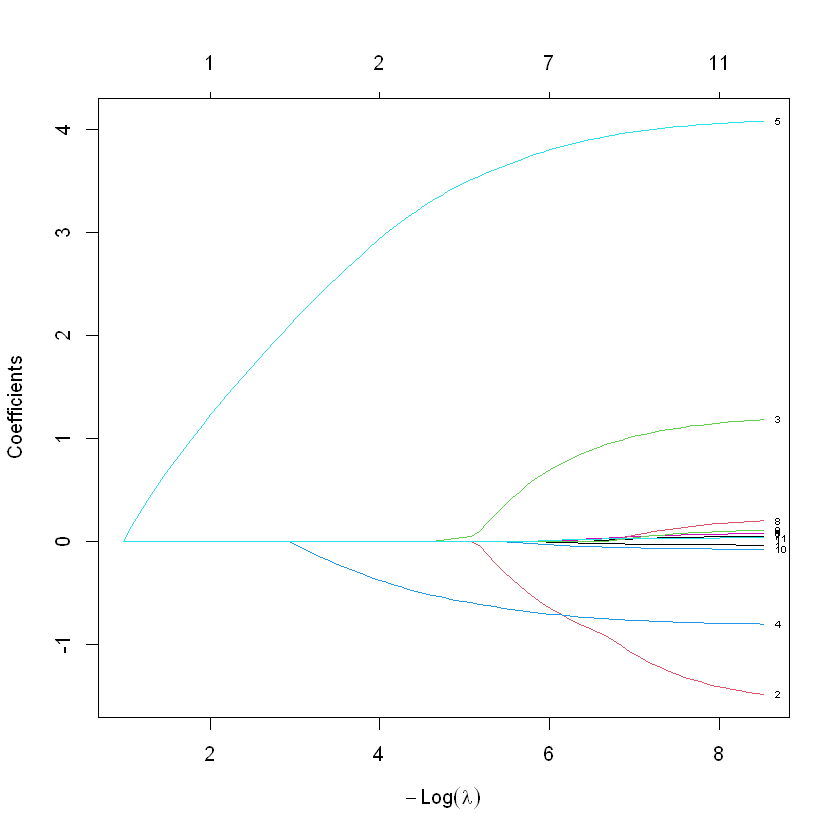

In [30]:
glmnet_fit <- fit_l1 %>%
  extract_fit_engine()
plot(glmnet_fit, xvar = "lambda", label = TRUE)

coef_l1 <- coef(glmnet_fit, s = glmnet_fit$lambda.min)

sum(coef_l1 != 0)

[1] 1200

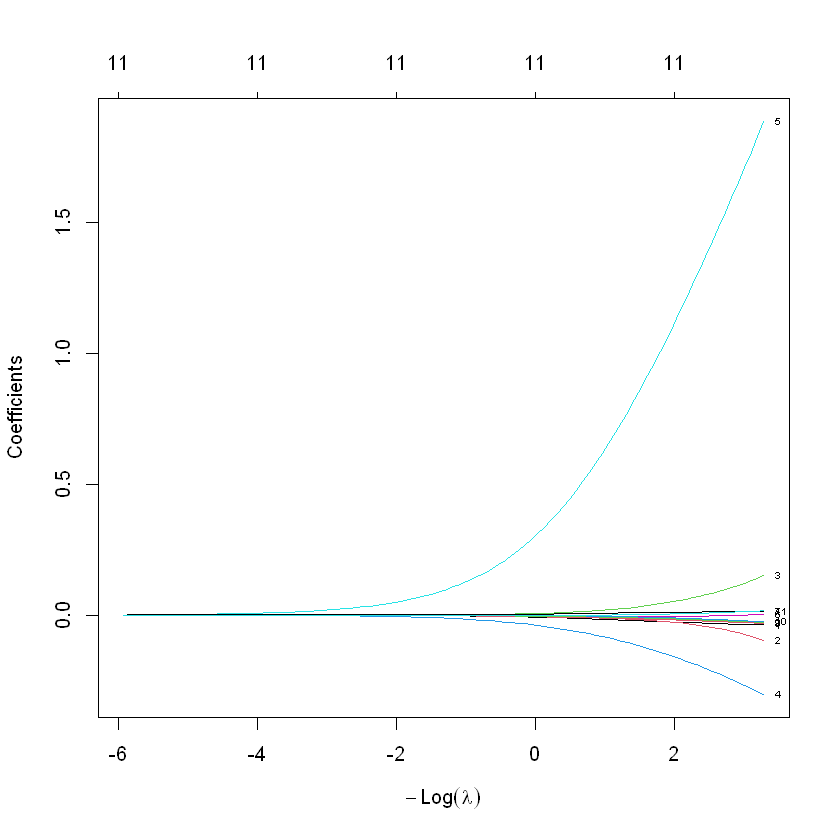

In [31]:
glmnet_fit <- fit_l2 %>%
  extract_fit_engine()
plot(glmnet_fit, xvar = "lambda", label = TRUE)

coef_l2 <- coef(glmnet_fit, s = glmnet_fit$lambda.min)

sum(coef_l2 != 0)

DEFAULT TIME

In [32]:
log_glm <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification")
#lasso
log_l1 <- logistic_reg(
  penalty = tune(),
  mixture = 1
) |>
  set_engine("glmnet") |>
  set_mode("classification")

log_l2 <- logistic_reg(
  penalty = tune(),
  mixture = 0
) |>
  set_engine("glmnet") |>
  set_mode("classification")

folds <- vfold_cv(train_data_default, v = 5, strata = PD30)


In [33]:
#modelo geral
rec_default  <- recipe(PD30 ~ ., data = train_data_default) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())
rec_all  <- recipe(PD30 ~ ., data = train_data_default) %>%
  step_dummy(all_nominal_predictors()) 

# Removendo alta correlação
rec_corr <- recipe(
  PD30 ~ .,
  data = train_data_default
) %>% step_dummy(all_nominal_predictors()) %>%
  step_corr(all_numeric_predictors(), threshold = 0.7)

#com pca
rec_pca <- recipe(
  PD30 ~ .,
  data = train_data_default
) %>% step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors()) %>%
  step_pca(all_numeric_predictors(), threshold = 0.95)

In [34]:
wf_logit_default <- workflow_set(
  preproc = list(
    all_features = rec_all,
    no_corr      = rec_corr
    #pca          = rec_pca
  ),
  models = list(
    logit = log_glm
  )
)
wf_l1 <- workflow() %>%
  add_recipe(rec_default) %>%
  add_model(log_l1)

tuned_l1 <- tune_grid(
  wf_l1,
  resamples = folds,
  grid = grid,
  metrics = metrics
)

wf_l2 <- workflow() %>%
  add_recipe(rec_default) %>%
  add_model(log_l2)

tuned_l2 <- tune_grid(
  wf_l2,
  resamples = folds,
  grid = grid,
  metrics = metrics
)

In [35]:
best_l1 <- select_best(tuned_l1, metric = "roc_auc")
final_l1 <- finalize_workflow(wf_l1, best_l1)
fit_l1 <- fit(final_l1, train_data_default)

best_l2 <- select_best(tuned_l2, metric = "roc_auc")
final_l2 <- finalize_workflow(wf_l2, best_l2)
fit_l2 <- fit(final_l2, train_data_default)

In [36]:
library(broom)

coef_table <- extract_fit_engine(fit_l1) |>
  coef(s = best_l1$penalty)
  coef_table

24 x 1 sparse Matrix of class "dgCMatrix"
                    s=1e-06
(Intercept)    -1.466639813
limite_credito -0.094661311
sexo           -0.035004786
escolaridade   -0.072950332
estado_civil   -0.089415722
idade           0.055133092
atraso_pagto_0  0.648918405
atraso_pagto_2  0.126711935
atraso_pagto_3  0.095425647
atraso_pagto_4  0.006374048
atraso_pagto_5  0.063915465
atraso_pagto_6 -0.001422033
fatura_valor_1 -0.328195526
fatura_valor_2  0.089114652
fatura_valor_3  0.072774015
fatura_valor_4  .          
fatura_valor_5  0.061297241
fatura_valor_6  .          
pagto_valor_1  -0.203277601
pagto_valor_2  -0.169973920
pagto_valor_3  -0.102813317
pagto_valor_4  -0.028684425
pagto_valor_5  -0.031330571
pagto_valor_6  -0.044343025

In [37]:
coef_table <- extract_fit_engine(fit_l2) |>
  coef(s = best_l2$penalty)
  coef_table

24 x 1 sparse Matrix of class "dgCMatrix"
                    s=1e-06
(Intercept)    -1.442426103
limite_credito -0.096639342
sexo           -0.032552769
escolaridade   -0.063921471
estado_civil   -0.082492064
idade           0.052174196
atraso_pagto_0  0.573329577
atraso_pagto_2  0.144283483
atraso_pagto_3  0.094010299
atraso_pagto_4  0.027315919
atraso_pagto_5  0.056828056
atraso_pagto_6  0.009917793
fatura_valor_1 -0.131804335
fatura_valor_2 -0.023115940
fatura_valor_3  0.003536904
fatura_valor_4 -0.006933742
fatura_valor_5  0.030241967
fatura_valor_6  0.019482572
pagto_valor_1  -0.142934747
pagto_valor_2  -0.122580500
pagto_valor_3  -0.091089024
pagto_valor_4  -0.037267639
pagto_valor_5  -0.042016896
pagto_valor_6  -0.048021788

In [38]:
fits <- wf_logit_default %>%
  mutate(
    fit = purrr::map(
      info,
      ~ fit(.x$workflow[[1]], data = train_data_default)
    )
  )

In [39]:
library(dplyr)
library(purrr)
library(yardstick)

preds <- fits %>%
  mutate(
    preds = purrr::map(
      fit,
      ~{
        prob_tbl <- predict(.x, test_data_default, type = "prob")

        tibble(
          truth = test_data_default$PD30,
          class = predict(.x, test_data_default, type = "class")$.pred_class,
          prob  = prob_tbl$.pred_1
        )
      }
    )
  ) %>%
  select(wflow_id, preds)

preds <- preds %>%
  tidyr::unnest(preds)

In [40]:
metrics_wf <- fits %>%
  mutate(
    metrics = purrr::map(
      fit,
      ~ calc_metrics_from_fit(
        fit = .x,
        test_data = test_data_default,
        truth_col = PD30
      )
    )
  ) %>%
  select(wflow_id, metrics) %>%
  tidyr::unnest(metrics)

metrics_l1 <- calc_metrics_from_fit(
  fit = fit_l1,
  test_data = test_data_default,
  truth_col = PD30
) %>%
  mutate(wflow_id = "l1_logit")
  
metrics_l2 <- calc_metrics_from_fit(
  fit = fit_l2,
  test_data = test_data_default,
  truth_col = PD30
) %>%
  mutate(wflow_id = "l2_logit")

metrics_table_final <- bind_rows(
  metrics_wf,
  metrics_l1,
  metrics_l2
)
metrics_table_final

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,f1,mcc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.8076000,0.6052354,0.7136508,0.4716959,0.9681561,0.2423146,0.8181424,0.8868502,0.3249886
no_corr_logit,0.8074667,0.6051498,0.7112449,0.4720875,0.9679849,0.2423146,0.8181160,0.8867629,0.3244719
l1_logit,0.8074667,0.6042867,0.7132359,0.4715931,0.9686697,0.2399036,0.8177482,0.8868339,0.3238290
l2_logit,0.8038667,0.5935598,0.7113678,0.4718171,0.9707242,0.2163954,0.8134864,0.8851768,0.3030622


In [41]:
model_summaries <- fits %>%
  mutate(
    summary = purrr::map(fit, extract_model_summary)
  ) %>%
  select(wflow_id, summary)
  
for (i in seq_len(nrow(model_summaries))) {
  cat("\n==============================\n")
  cat("Modelo:", model_summaries$wflow_id[i], "\n")
  cat("==============================\n\n")
  print(model_summaries$summary[[i]])
}


Modelo: all_features_logit 


Call:
stats::glm(formula = ..y ~ ., family = stats::binomial, data = data)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -6.803e-01  1.378e-01  -4.938 7.91e-07 ***
limite_credito -7.299e-07  1.825e-07  -4.001 6.32e-05 ***
sexo           -7.383e-02  3.562e-02  -2.073 0.038188 *  
escolaridade   -9.555e-02  2.435e-02  -3.924 8.71e-05 ***
estado_civil   -1.739e-01  3.671e-02  -4.738 2.16e-06 ***
idade           6.116e-03  2.072e-03   2.952 0.003159 ** 
atraso_pagto_0  5.762e-01  2.047e-02  28.153  < 2e-16 ***
atraso_pagto_2  1.075e-01  2.331e-02   4.609 4.04e-06 ***
atraso_pagto_3  7.866e-02  2.615e-02   3.008 0.002629 ** 
atraso_pagto_4  5.961e-03  2.886e-02   0.207 0.836393    
atraso_pagto_5  6.156e-02  3.115e-02   1.976 0.048116 *  
atraso_pagto_6 -8.482e-03  2.586e-02  -0.328 0.742944    
fatura_valor_1 -5.770e-06  1.320e-06  -4.372 1.23e-05 ***
fatura_valor_2  2.651e-06  1.744e-06   1.520 0.128504    
fatura_va

In [42]:
metrics_table_final

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,f1,mcc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.8076000,0.6052354,0.7136508,0.4716959,0.9681561,0.2423146,0.8181424,0.8868502,0.3249886
no_corr_logit,0.8074667,0.6051498,0.7112449,0.4720875,0.9679849,0.2423146,0.8181160,0.8867629,0.3244719
l1_logit,0.8074667,0.6042867,0.7132359,0.4715931,0.9686697,0.2399036,0.8177482,0.8868339,0.3238290
l2_logit,0.8038667,0.5935598,0.7113678,0.4718171,0.9707242,0.2163954,0.8134864,0.8851768,0.3030622


In [43]:
fits_vif <- fits %>%
  dplyr::filter(
    wflow_id %in% c(
      "all_features_logit",
      "no_corr_logit"
    )
  )

vif_results <- fits_vif %>%
  mutate(
    vif = purrr::map(fit, calc_vif)
  )
vif_tidy <- vif_results %>%
  select(wflow_id, vif) %>%
  tidyr::unnest_longer(vif, values_to = "vif") %>%
  rename(variable = vif_id)

vif_summary <- vif_tidy %>%
  group_by(wflow_id) %>%
  summarise(
    max_vif = max(vif),
    mean_vif = mean(vif)
  )

In [44]:
library(dplyr)

model_summary <- metrics_table_final %>%
  left_join(
    vif_summary %>%
      group_by(wflow_id) %>%
      summarise(
        max_vif = max(max_vif, na.rm = TRUE),
        mean_vif = mean(mean_vif, na.rm = TRUE)
      ),
    by = "wflow_id"
  )
model_summary

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,f1,mcc,max_vif,mean_vif
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.8076000,0.6052354,0.7136508,0.4716959,0.9681561,0.2423146,0.8181424,0.8868502,0.3249886,40.704661,8.905201
no_corr_logit,0.8074667,0.6051498,0.7112449,0.4720875,0.9679849,0.2423146,0.8181160,0.8867629,0.3244719,1.846763,1.257340
l1_logit,0.8074667,0.6042867,0.7132359,0.4715931,0.9686697,0.2399036,0.8177482,0.8868339,0.3238290,NA,NA
l2_logit,0.8038667,0.5935598,0.7113678,0.4718171,0.9707242,0.2163954,0.8134864,0.8851768,0.3030622,NA,NA


In [45]:
get_model <- function(wf_fit) {
  workflows::extract_fit_parsnip(wf_fit)$fit
}

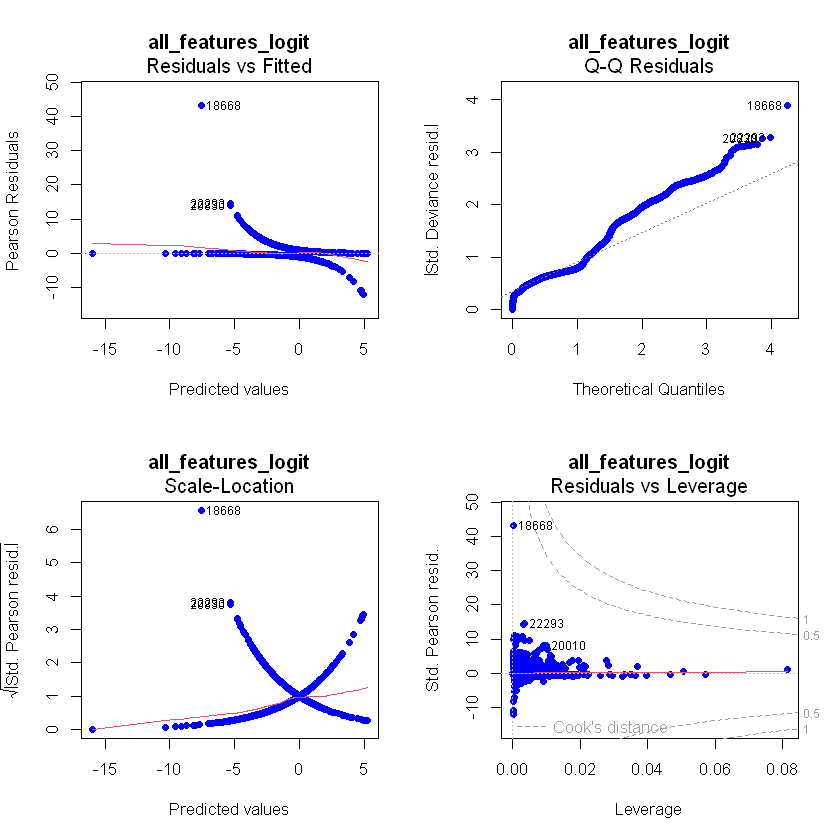

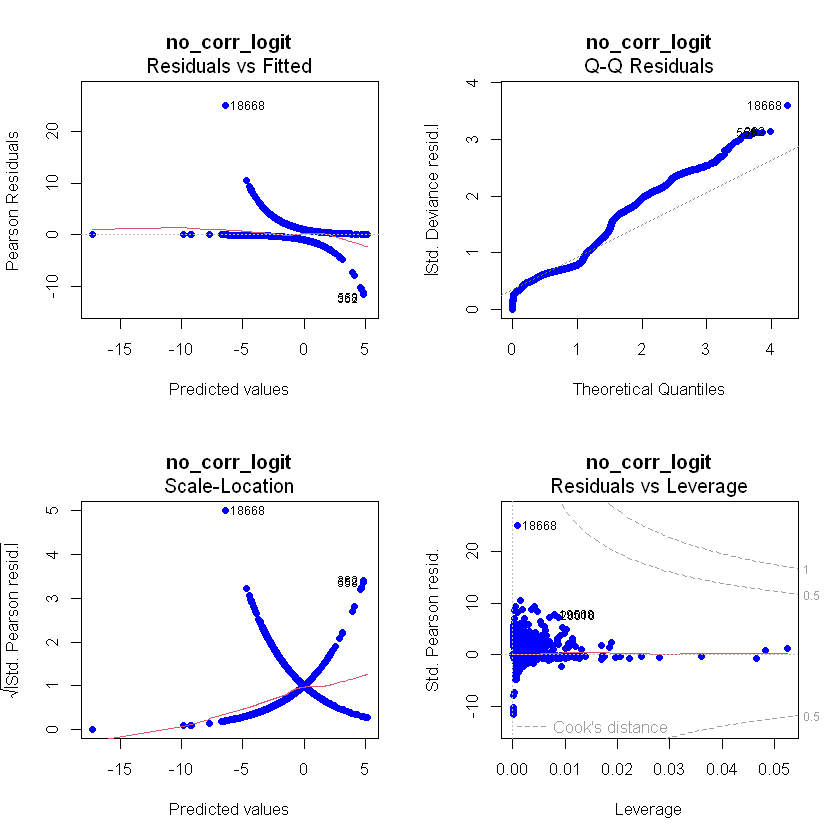

In [46]:
purrr::walk2(
  fits$fit,
  fits$wflow_id,
  ~ {
    modelo <- get_model(.x)

    par(mfrow = c(2, 2))
    plot(
      modelo,
      pch = 19,
      col = "blue",
      main = .y
    )
  }
)

[1] 919

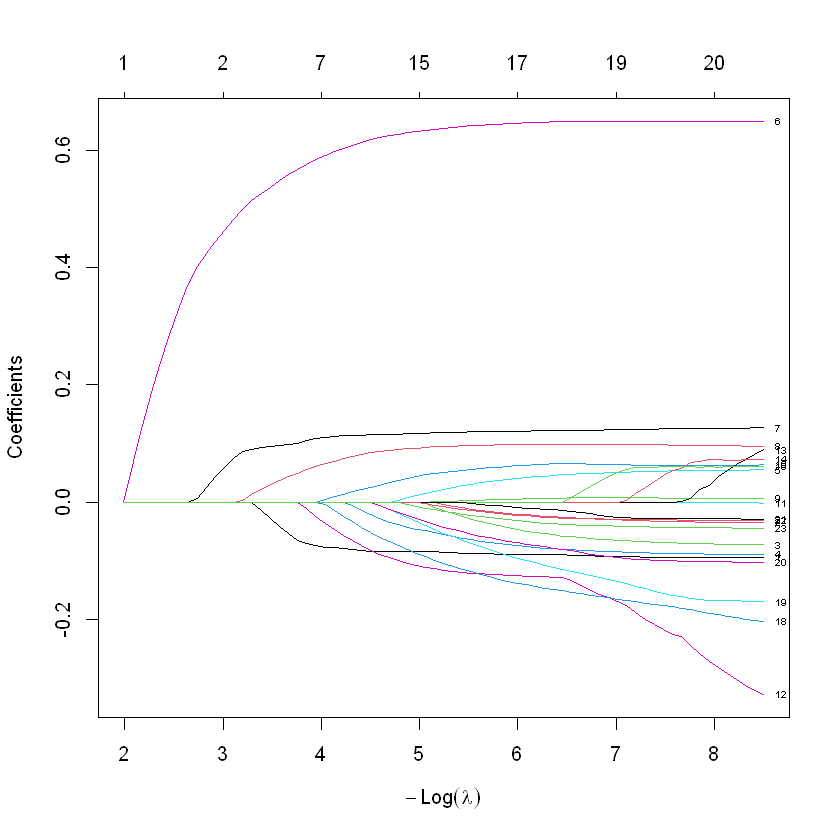

In [47]:
glmnet_fit <- fit_l1 %>%
  extract_fit_engine()
plot(glmnet_fit, xvar = "lambda", label = TRUE)

coef_l1 <- coef(glmnet_fit, s = glmnet_fit$lambda.min)

sum(coef_l1 != 0)

[1] 2400

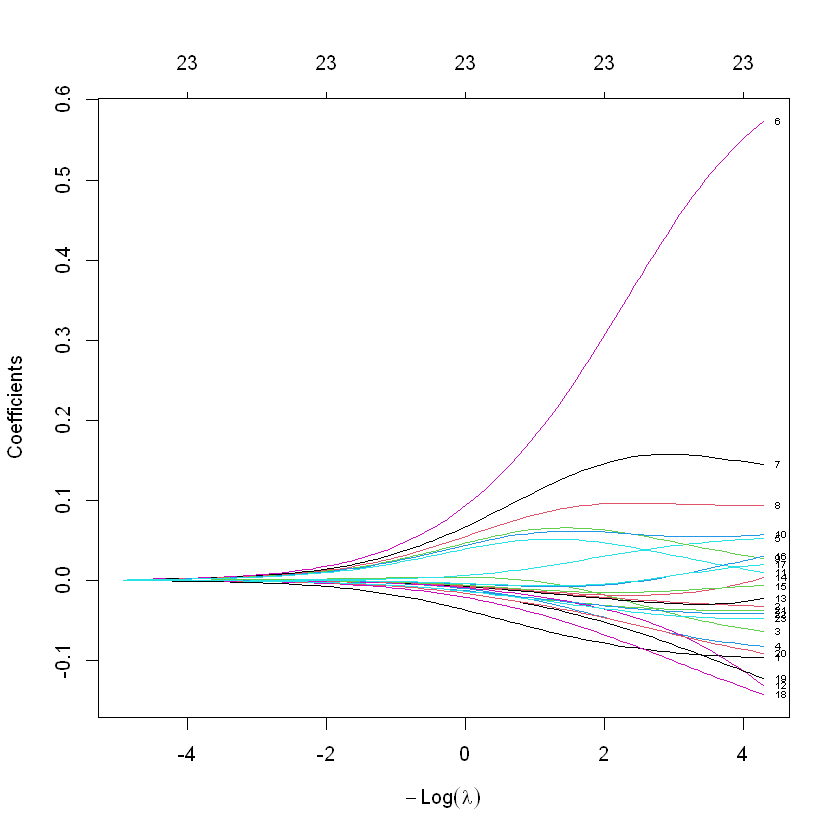

In [48]:
glmnet_fit <- fit_l2 %>%
  extract_fit_engine()
plot(glmnet_fit, xvar = "lambda", label = TRUE)

coef_l2 <- coef(glmnet_fit, s = glmnet_fit$lambda.min)

sum(coef_l2 != 0)

In [49]:
install.packages("Rtools")

Instalando pacote em 'C:/Users/T-GAMER/AppData/Local/R/win-library/4.5'
(como 'lib' não foi especificado)

Warning message:
"pacote 'Rtools' não está disponível for this version of R

Uma versão deste pacote para a sua versão do R pode estar disponível em outro lugar,
veja as ideias em
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"


In [50]:
library(rstanarm)

In [51]:
rec_score <- recipe(status ~ score_credito, data = train_data_loan) %>%
  step_normalize(score_credito)
rec_prep <- prep(rec_score)

train_bayes <- bake(
  rec_prep,
  new_data = NULL
)

test_bayes <- bake(
  rec_prep,
  new_data = test_data_loan
)

In [52]:
# Não informativa
prior_noninformative <- normal(location = 0, scale = 10, autoscale = FALSE)

fit_p1 <- stan_glm(
  status ~ score_credito,
  data = train_bayes,
  family = binomial(link = "logit"),
  prior = normal(0, 10),
  prior_intercept = normal(0, 10),
  chains = 4,
  iter = 4000,
  seed = 123
)


SAMPLING FOR MODEL 'bernoulli' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.002674 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 26.74 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 4000 [  0%]  (Warmup)
Chain 1: Iteration:  400 / 4000 [ 10%]  (Warmup)
Chain 1: Iteration:  800 / 4000 [ 20%]  (Warmup)
Chain 1: Iteration: 1200 / 4000 [ 30%]  (Warmup)
Chain 1: Iteration: 1600 / 4000 [ 40%]  (Warmup)
Chain 1: Iteration: 2000 / 4000 [ 50%]  (Warmup)
Chain 1: Iteration: 2001 / 4000 [ 50%]  (Sampling)
Chain 1: Iteration: 2400 / 4000 [ 60%]  (Sampling)
Chain 1: Iteration: 2800 / 4000 [ 70%]  (Sampling)
Chain 1: Iteration: 3200 / 4000 [ 80%]  (Sampling)
Chain 1: Iteration: 3600 / 4000 [ 90%]  (Sampling)
Chain 1: Iteration: 4000 / 4000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 2.698 seconds (Warm-up)
Chain 1:                2.874 seconds (Sampling)
Chain 1:                5.5

In [53]:
#🔹 Prior 2 — Regularizadora fraca
prior_weak <- normal(location = 0, scale = 2.5, autoscale = FALSE)

fit_p2 <- stan_glm(
  status ~ score_credito,
  data = train_bayes,
  family = binomial(link = "logit"),
  prior = normal(0, 2.5),
  prior_intercept = normal(0, 5),
  chains = 4,
  iter = 4000,
  seed = 123
)


SAMPLING FOR MODEL 'bernoulli' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000206 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 2.06 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 4000 [  0%]  (Warmup)
Chain 1: Iteration:  400 / 4000 [ 10%]  (Warmup)
Chain 1: Iteration:  800 / 4000 [ 20%]  (Warmup)
Chain 1: Iteration: 1200 / 4000 [ 30%]  (Warmup)
Chain 1: Iteration: 1600 / 4000 [ 40%]  (Warmup)
Chain 1: Iteration: 2000 / 4000 [ 50%]  (Warmup)
Chain 1: Iteration: 2001 / 4000 [ 50%]  (Sampling)
Chain 1: Iteration: 2400 / 4000 [ 60%]  (Sampling)
Chain 1: Iteration: 2800 / 4000 [ 70%]  (Sampling)
Chain 1: Iteration: 3200 / 4000 [ 80%]  (Sampling)
Chain 1: Iteration: 3600 / 4000 [ 90%]  (Sampling)
Chain 1: Iteration: 4000 / 4000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 2.619 seconds (Warm-up)
Chain 1:                2.765 seconds (Sampling)
Chain 1:                5.38

In [54]:
#🔹 Prior 3 — Informativa (sem truncamento)
prior_informative <- normal(location = 0.5, scale = 0.25, autoscale = FALSE)

fit_p3 <- stan_glm(
  status ~ score_credito,
  data = train_bayes,
  family = binomial(link = "logit"),
  prior = normal(0.5, 0.25),
  prior_intercept = normal(0, 2.5),
  chains = 4,
  iter = 4000,
  seed = 123
)


SAMPLING FOR MODEL 'bernoulli' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000242 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 2.42 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 4000 [  0%]  (Warmup)
Chain 1: Iteration:  400 / 4000 [ 10%]  (Warmup)
Chain 1: Iteration:  800 / 4000 [ 20%]  (Warmup)
Chain 1: Iteration: 1200 / 4000 [ 30%]  (Warmup)
Chain 1: Iteration: 1600 / 4000 [ 40%]  (Warmup)
Chain 1: Iteration: 2000 / 4000 [ 50%]  (Warmup)
Chain 1: Iteration: 2001 / 4000 [ 50%]  (Sampling)
Chain 1: Iteration: 2400 / 4000 [ 60%]  (Sampling)
Chain 1: Iteration: 2800 / 4000 [ 70%]  (Sampling)
Chain 1: Iteration: 3200 / 4000 [ 80%]  (Sampling)
Chain 1: Iteration: 3600 / 4000 [ 90%]  (Sampling)
Chain 1: Iteration: 4000 / 4000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 2.615 seconds (Warm-up)
Chain 1:                2.609 seconds (Sampling)
Chain 1:                5.22

In [55]:
library(yardstick)
 
pred_p1 <- posterior_epred(fit_p1, newdata = test_bayes) %>% colMeans()
pred_p2 <- posterior_epred(fit_p2, newdata = test_bayes) %>% colMeans()
pred_p3 <- posterior_epred(fit_p3, newdata = test_bayes) %>% colMeans()

In [56]:
calc_metrics_bay <- function(truth, class, prob) {

  tibble(
    accuracy     = accuracy_vec(truth, class),
    bal_accuracy = bal_accuracy_vec(truth, class),

    roc_auc  = roc_auc_vec(truth, prob, event_level = "second"),
    log_loss = mn_log_loss_vec(truth, prob),

    sens = sens_vec(truth, class),
    spec = spec_vec(truth, class),

    precision = precision_vec(truth, class),
    npv       = npv_vec(truth, class),

    f1 = f_meas_vec(truth, class),
    f2 = f_meas_vec(truth, class, beta = 2),

    kap = kap_vec(truth, class),
    mcc = mcc_vec(truth, class),

    gmean = sqrt(
      sens_vec(truth, class) *
      spec_vec(truth, class)
    )
  )
}


In [57]:
calc_metrics_bayes <- function(fit, test_data, model_name) {
  
  # Probabilidade posterior média
  prob <- posterior_epred(
    fit,
    newdata = test_data
  ) %>%
    colMeans()
  
  # Classificação
  class <- ifelse(
    prob >= 0.5,
    "1",
    "0"
  ) %>%
    factor(
      levels = levels(test_data$status)
    )
  
  # Verdade
  truth <- test_data$status
  
  calc_metrics_bay(
    truth = truth,
    class = class,
    prob = prob
  ) %>%
    mutate(
      wflow_id = model_name
    )
}

In [58]:
metrics_p1 <- calc_metrics_bayes(
  fit = fit_p1,
  test_data = test_bayes,
  model_name = "bayes_prior_1"
)

metrics_p2 <- calc_metrics_bayes(
  fit = fit_p2,
  test_data = test_bayes,
  model_name = "bayes_prior_2"
)

metrics_p3 <- calc_metrics_bayes(
  fit = fit_p3,
  test_data = test_bayes,
  model_name = "bayes_prior_3"
)


In [59]:
metrics_table_loan_all <- bind_rows(
  metrics_table_final_loan,
  metrics_p1,
  metrics_p2,
  metrics_p3
)
metrics_table_loan_all

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,f1,mcc,npv,f2,kap,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9269663,0.9228498,0.9762018,0.1951876,0.90594059,0.9397590,0.9014778,0.90370370,0.84488744,NA,NA,NA,NA
score_only_logit,0.9213483,0.9173625,0.9651769,0.2362452,0.90099010,0.9337349,0.8921569,0.89655172,0.83313641,NA,NA,NA,NA
no_score_logit,0.6207865,0.5065162,0.6161838,0.6461995,0.03712871,0.9759036,0.4838710,0.06896552,0.03764666,NA,NA,NA,NA
no_corr_logit,0.9307116,0.9278003,0.9736334,0.2061840,0.91584158,0.9397590,0.9024390,0.90909091,0.85318053,NA,NA,NA,NA
l1_logit,0.9260300,0.9220968,0.9760154,0.1997227,0.90594059,0.9382530,0.8992629,0.90258940,0.84298306,NA,NA,NA,NA
l2_logit,0.9269663,0.9199421,0.9743342,0.2802624,0.89108911,0.9487952,0.9137056,0.90225564,0.84414319,NA,NA,NA,NA
bayes_prior_1,0.9213483,0.9173625,0.9651769,3.2171273,0.90099010,0.9337349,0.8921569,0.89655172,0.83313641,0.9393939,0.8992095,0.8331101,0.9172164
bayes_prior_2,0.9213483,0.9173625,0.9651769,3.2047655,0.90099010,0.9337349,0.8921569,0.89655172,0.83313641,0.9393939,0.8992095,0.8331101,0.9172164
bayes_prior_3,0.9194757,0.9148873,0.9651769,2.7631413,0.89603960,0.9337349,0.8916256,0.89382716,0.82897764,0.9365559,0.8951533,0.8289711,0.9146931


In [60]:
posterior_interval(fit_p1)
posterior_interval(fit_p3)

,5%,95%
(Intercept),1.380859,1.649898
score_credito,3.394910,3.829870


,5%,95%
(Intercept),1.176178,1.399741
score_credito,2.882466,3.204822


In [61]:
prob_p1 <- posterior_epred(
  fit_p1,
  newdata = test_data_loan
) %>%
  colMeans()


pred_p1 <- tibble(
  truth = test_data_loan$status,
  class = ifelse(prob_p1 >= 0.5, "1", "0"),
  prob = prob_p1
)

In [62]:
summary(fit_p1)


Model Info:
 function:     stan_glm
 family:       binomial [logit]
 formula:      status ~ score_credito
 algorithm:    sampling
 sample:       8000 (posterior sample size)
 priors:       see help('prior_summary')
 observations: 3201
 predictors:   2

Estimates:
                mean   sd   10%   50%   90%
(Intercept)   1.5    0.1  1.4   1.5   1.6  
score_credito 3.6    0.1  3.4   3.6   3.8  

Fit Diagnostics:
           mean   sd   10%   50%   90%
mean_PPD 0.6    0.0  0.6   0.6   0.6  

The mean_ppd is the sample average posterior predictive distribution of the outcome variable (for details see help('summary.stanreg')).

MCMC diagnostics
              mcse Rhat n_eff
(Intercept)   0.0  1.0  2527 
score_credito 0.0  1.0  2706 
mean_PPD      0.0  1.0  5793 
log-posterior 0.0  1.0  2560 

For each parameter, mcse is Monte Carlo standard error, n_eff is a crude measure of effective sample size, and Rhat is the potential scale reduction factor on split chains (at convergence Rhat=1).

In [63]:
library(recipes)

rec_default <- recipe(PD30 ~ ., data = train_data_default) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())
rec_prep <- prep(rec_default)

In [64]:
train_bayes <- bake(
  rec_prep,
  new_data = NULL
)

test_bayes <- bake(
  rec_prep,
  new_data = test_data_default
)

In [65]:
fit_or_load <- function(path, fit_expr) {

  if (file.exists(path)) {

    message("Modelo carregado de: ", path)
    return(readRDS(path))

  }

  message("Treinando modelo...")

  fit <- eval.parent(substitute(fit_expr))

  saveRDS(fit, path)

  message("Modelo salvo em: ", path)

  fit
}

In [66]:
dir.create("models", showWarnings = FALSE)

In [67]:
fit_normal <- fit_or_load(
  "models/fit_prior_normal.rds",
  stan_glm(
  PD30 ~ .,
  data = train_bayes,
  family = binomial(link = "logit"),

  prior = normal(
    location = 0,
    scale = 1,
    autoscale = FALSE
  ),

  prior_intercept = normal(
    location = 0,
    scale = 5,
    autoscale = FALSE
  ),

  chains = 4,
  iter = 1000,
  warmup = 500,
  seed = 123
)
)
#Todos os coeficientes recebem contração uniforme.

Modelo carregado de: models/fit_prior_normal.rds



In [68]:
fit_laplace <- fit_or_load(
  "models/fit_prior_laplace.rds",
  stan_glm(
    PD30 ~ .,
    data = train_bayes,
    family = binomial(link = "logit"),

  prior = laplace(
    location = 0,
    scale = 1,
    autoscale = FALSE
  ),

  prior_intercept = normal(
    0,
    5,
    autoscale = FALSE
  ),

  chains = 4,
  iter = 1000,
  warmup = 500,
  seed = 123
)
)
#Todos os coeficientes sofrem contração, porém alguns podem aproximar-se de zero com maior intensidade.

Modelo carregado de: models/fit_prior_laplace.rds



In [69]:
fit_horseshoe <- fit_or_load(
  "models/fit_prior_horseshoe.rds",
  stan_glm(
    PD30 ~ .,
    data = train_bayes,
    family = binomial(link = "logit"),

  prior = hs(),

  prior_intercept = normal(
    0,
    5,
    autoscale = FALSE
  ),

  chains = 4,
  iter = 1000,
  warmup = 500,
  seed = 123
)
)
#A contração passa a ser adaptativa, preservando grandes efeitos e reduzindo fortemente coeficientes associados a variáveis pouco informativas.

Modelo carregado de: models/fit_prior_horseshoe.rds



In [70]:
pred_hs <- posterior_epred(fit_horseshoe, newdata = test_bayes) %>% colMeans()
pred_lp <- posterior_epred(fit_laplace, newdata = test_bayes) %>% colMeans()
pred_norm <- posterior_epred(fit_normal, newdata = test_bayes) %>% colMeans()

In [71]:
calc_metrics_bayes <- function(fit, test_data, model_name) {
  
  # Probabilidade posterior média
  prob <- posterior_epred(
    fit,
    newdata = test_data
  ) %>%
    colMeans()
  
  # Classificação
  class <- ifelse(
    prob >= 0.5,
    "1",
    "0"
  ) %>%
    factor(
      levels = levels(test_data$PD30)
    )
  
  # Verdade
  truth <- test_data$PD30
  
  calc_metrics_bay(
    truth = truth,
    class = class,
    prob = prob
  ) %>%
    mutate(
      wflow_id = model_name
    )
}

In [72]:
metrics_p1 <- calc_metrics_bayes(
  fit = fit_horseshoe,
  test_data = test_bayes,
  model_name = "bayes_prior_horse"
)

metrics_p2 <- calc_metrics_bayes(
  fit = fit_laplace,
  test_data = test_bayes,
  model_name = "bayes_prior_l1"
)

metrics_p3 <- calc_metrics_bayes(
  fit = fit_normal,
  test_data = test_bayes,
  model_name = "bayes_prior_normal"
)

In [73]:
summary(fit_laplace)


Model Info:
 function:     stan_glm
 family:       binomial [logit]
 formula:      PD30 ~ .
 algorithm:    sampling
 sample:       2000 (posterior sample size)
 priors:       see help('prior_summary')
 observations: 22500
 predictors:   24

Estimates:
                 mean   sd   10%   50%   90%
(Intercept)    -1.5    0.0 -1.5  -1.5  -1.4 
limite_credito -0.1    0.0 -0.1  -0.1  -0.1 
sexo            0.0    0.0 -0.1   0.0   0.0 
escolaridade   -0.1    0.0 -0.1  -0.1  -0.1 
estado_civil   -0.1    0.0 -0.1  -0.1  -0.1 
idade           0.1    0.0  0.0   0.1   0.1 
atraso_pagto_0  0.6    0.0  0.6   0.6   0.7 
atraso_pagto_2  0.1    0.0  0.1   0.1   0.2 
atraso_pagto_3  0.1    0.0  0.1   0.1   0.1 
atraso_pagto_4  0.0    0.0  0.0   0.0   0.1 
atraso_pagto_5  0.1    0.0  0.0   0.1   0.1 
atraso_pagto_6  0.0    0.0  0.0   0.0   0.0 
fatura_valor_1 -0.4    0.1 -0.5  -0.4  -0.3 
fatura_valor_2  0.2    0.1  0.0   0.2   0.3 
fatura_valor_3  0.1    0.1  0.0   0.1   0.2 
fatura_valor_4 -0.1    0.1 

In [74]:
summary(fit_horseshoe)


Model Info:
 function:     stan_glm
 family:       binomial [logit]
 formula:      PD30 ~ .
 algorithm:    sampling
 sample:       2000 (posterior sample size)
 priors:       see help('prior_summary')
 observations: 22500
 predictors:   24

Estimates:
                 mean   sd   10%   50%   90%
(Intercept)    -1.5    0.0 -1.5  -1.5  -1.4 
limite_credito -0.1    0.0 -0.1  -0.1  -0.1 
sexo            0.0    0.0 -0.1   0.0   0.0 
escolaridade   -0.1    0.0 -0.1  -0.1   0.0 
estado_civil   -0.1    0.0 -0.1  -0.1  -0.1 
idade           0.1    0.0  0.0   0.1   0.1 
atraso_pagto_0  0.7    0.0  0.6   0.7   0.7 
atraso_pagto_2  0.1    0.0  0.1   0.1   0.2 
atraso_pagto_3  0.1    0.0  0.1   0.1   0.1 
atraso_pagto_4  0.0    0.0  0.0   0.0   0.0 
atraso_pagto_5  0.1    0.0  0.0   0.1   0.1 
atraso_pagto_6  0.0    0.0  0.0   0.0   0.0 
fatura_valor_1 -0.3    0.1 -0.4  -0.3  -0.2 
fatura_valor_2  0.1    0.1  0.0   0.1   0.2 
fatura_valor_3  0.1    0.1  0.0   0.0   0.2 
fatura_valor_4  0.0    0.1 

In [ ]:
metrics_table_all <- bind_rows(
  metrics_table_final,
  metrics_p1,
  metrics_p2,
  metrics_p3,

)
metrics_table_all

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,f1,mcc,npv,f2,kap,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.8076000,0.6052354,0.7136508,0.4716959,0.9681561,0.2423146,0.8181424,0.8868502,0.3249886,NA,NA,NA,NA
no_corr_logit,0.8074667,0.6051498,0.7112449,0.4720875,0.9679849,0.2423146,0.8181160,0.8867629,0.3244719,NA,NA,NA,NA
l1_logit,0.8074667,0.6042867,0.7132359,0.4715931,0.9686697,0.2399036,0.8177482,0.8868339,0.3238290,NA,NA,NA,NA
l2_logit,0.8038667,0.5935598,0.7113678,0.4718171,0.9707242,0.2163954,0.8134864,0.8851768,0.3030622,NA,NA,NA,NA
bayes_prior_horse,0.8078667,0.6047592,0.7129307,1.5517381,0.9690122,0.2405063,0.8179191,0.8870778,0.3255533,0.6879310,0.9344869,0.2731062,0.4827562
bayes_prior_l1,0.8074667,0.6047182,0.7137742,1.5585211,0.9683273,0.2411091,0.8179320,0.8867984,0.3241493,0.6837607,0.9339806,0.2726159,0.4831900
bayes_prior_normal,0.8078667,0.6054066,0.7138347,1.5589486,0.9684985,0.2423146,0.8181950,0.8870247,0.3260251,0.6860068,0.9341766,0.2743309,0.4844392


: 